# Part 2: Deep Q-Learning on Atari Pong

> **Note:** This notebook requires a GPU for practical training speeds. Run on Google Colab with a GPU runtime (`Runtime -> Change runtime type -> T4 GPU`).

In this notebook we extend tabular Q-learning from Part 1 to **Deep Q-Learning (DQN)**, where a convolutional neural network approximates the Q-function. We apply it to the Atari game **Pong**.

Key differences from tabular Q-learning:

| Aspect | Tabular Q-Learning | Deep Q-Learning |
|---|---|---|
| Q-function | Lookup table | CNN |
| State space | Discrete, small | Raw pixels (210x160x3) |
| Generalization | None | Learned across similar states |
| Training signal | Direct TD update | Mini-batch gradient descent |
| Stability tricks | None needed | Replay buffer + target network |

**Pong** was chosen because it has a clear reward signal (+1/-1 per point), few effective actions, and converges faster than other Atari games.

In [2]:
!pip install gymnasium[atari] ale-py
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

## 1. Setup and Installation

In [1]:
# Uncomment and run once to install dependencies
!pip install gymnasium[atari,accept-rom-license] torch ale-py opencv-python-headless tqdm

In [3]:
import random
import time
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing

# FrameStack was renamed to FrameStackObservation in gymnasium 1.0
# and the keyword argument changed from num_stack to stack_size
try:
    from gymnasium.wrappers import FrameStack
    _frame_stack_kwargs = lambda n: {'num_stack': n}
except ImportError:
    from gymnasium.wrappers import FrameStackObservation as FrameStack
    _frame_stack_kwargs = lambda n: {'stack_size': n}

def make_frame_stack(env, n):
    return FrameStack(env, **_frame_stack_kwargs(n))

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda
GPU: Tesla T4


## 2. Environment and Preprocessing

Raw Atari frames (210x160x3 RGB) are too large and redundant to feed directly into a Q-network. We apply the standard preprocessing pipeline:

1. **No-op reset** - take 0-30 random no-ops at episode start for diverse starting states
2. **Frame skip** - repeat each action for 4 frames and take the max over the last 2 (handles sprite flickering)
3. **Life loss as terminal** - treat losing a life as a done signal for faster learning
4. **Grayscale + resize** - convert to 84x84 grayscale to reduce input size
5. **Frame stacking** - stack 4 consecutive frames to give the network motion information

`gymnasium.wrappers.AtariPreprocessing` handles steps 1-4. `FrameStack` handles step 5.

Raw observation shape: (210, 160, 3)
Action space: Discrete(6)
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


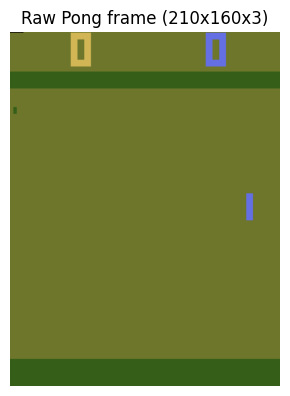

In [5]:
env_raw = gym.make('ALE/Pong-v5', render_mode='rgb_array', frameskip=1)
obs, _ = env_raw.reset()
print(f'Raw observation shape: {obs.shape}')
print(f'Action space: {env_raw.action_space}')
print(f'Action meanings: {env_raw.unwrapped.get_action_meanings()}')

plt.figure(figsize=(3, 5))
plt.imshow(obs)
plt.axis('off')
plt.title('Raw Pong frame (210x160x3)')
plt.tight_layout()
plt.show()
env_raw.close()

Wrapped obs shape: (4, 84, 84)
Dtype: uint8  |  Range: [52, 236]


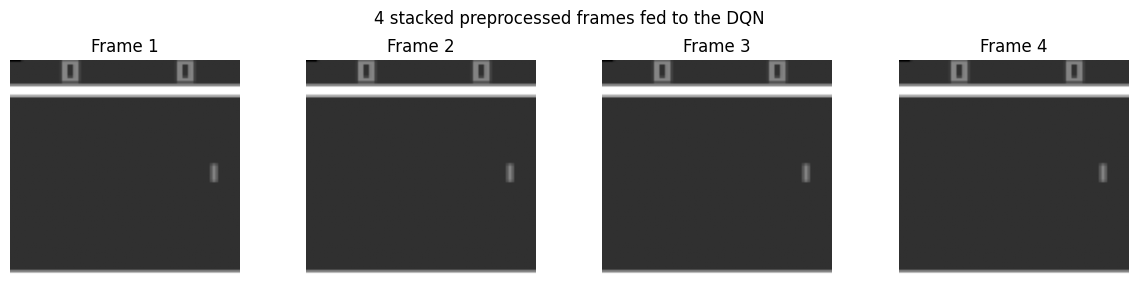

In [6]:
def make_env(env_id='ALE/Pong-v5', seed=42):
    """Create a preprocessed, frame-stacked Atari environment."""
    env = gym.make(env_id, render_mode='rgb_array', frameskip=1)  # disable built-in frameskip
    env = AtariPreprocessing(
        env,
        noop_max=30,               # random no-ops at reset
        frame_skip=4,              # repeat action for 4 frames
        screen_size=84,            # resize to 84x84
        terminal_on_life_loss=True,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,           # keep uint8 (0-255) to save 4x RAM in replay buffer
    )
    env = make_frame_stack(env, 4)  # stack 4 frames for motion
    env.action_space.seed(seed)
    return env


# Verify shapes
env_test = make_env(seed=SEED)
obs, _ = env_test.reset()
obs_arr = np.array(obs)
print(f'Wrapped obs shape: {obs_arr.shape}')   # expect (4, 84, 84)
print(f'Dtype: {obs_arr.dtype}  |  Range: [{obs_arr.min()}, {obs_arr.max()}]')  # uint8, 0-255

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(obs_arr[i], cmap='gray')
    ax.set_title(f'Frame {i + 1}')
    ax.axis('off')
plt.suptitle('4 stacked preprocessed frames fed to the DQN')
plt.tight_layout()
plt.show()
env_test.close()

## 3. Replay Buffer

The replay buffer stores past `(state, action, reward, next_state, done)` transitions and provides random mini-batch sampling. This breaks the temporal correlation between consecutive samples, which would otherwise destabilize neural network training.

In [7]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    """Fixed-capacity circular buffer for experience replay.

    States are stored as uint8 (0-255) to use 4x less RAM than float32.
    Conversion to float32 and normalization to [0, 1] happens on sampling.
    Memory cost: 50k transitions x 2 x (4 x 84 x 84) bytes ~= 2.8 GB.
    """

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(
            np.array(state, dtype=np.uint8),       # store as uint8 to save RAM
            action,
            float(reward),
            np.array(next_state, dtype=np.uint8),
            float(done),
        ))

    def sample(self, batch_size):
        batch = Transition(*zip(*random.sample(self.buffer, batch_size)))
        # Convert uint8 -> float32 and normalize to [0, 1] only at training time
        states      = torch.tensor(np.stack(batch.state),      device=device).float() / 255.0
        actions     = torch.tensor(batch.action,               device=device, dtype=torch.long).unsqueeze(1)
        rewards     = torch.tensor(batch.reward,               device=device, dtype=torch.float32)
        next_states = torch.tensor(np.stack(batch.next_state), device=device).float() / 255.0
        dones       = torch.tensor(batch.done,                 device=device, dtype=torch.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


print('ReplayBuffer defined.')

ReplayBuffer defined.


## 4. DQN Network Architecture

We use the convolutional architecture from the original DeepMind DQN paper (Mnih et al., 2015):

```
Input:  (batch, 4, 84, 84)  - 4 stacked grayscale frames
Conv2d(4,  32, kernel=8, stride=4)  -> ReLU   # (32, 20, 20)
Conv2d(32, 64, kernel=4, stride=2)  -> ReLU   # (64,  9,  9)
Conv2d(64, 64, kernel=3, stride=1)  -> ReLU   # (64,  7,  7)
Flatten -> Linear(3136, 512)        -> ReLU
Linear(512, n_actions)              -> Q-values per action
```

We maintain two copies: the **online network** (trained every step) and the **target network** (updated every 1000 steps). The target network provides stable TD targets.

In [8]:
class DQN(nn.Module):
    """
    DeepMind DQN convolutional network.
    Input:  (batch, 4, 84, 84)
    Output: (batch, n_actions)
    """
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4,  32, kernel_size=8, stride=4),  # -> (32, 20, 20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # -> (64,  9,  9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # -> (64,  7,  7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# Sanity check: verify output shape
_net = DQN(6).to(device)
_x = torch.zeros(1, 4, 84, 84, device=device)
print(f'Output shape: {_net(_x).shape}')  # expect torch.Size([1, 6])
del _net, _x

Output shape: torch.Size([1, 6])


## 5. Training

### Algorithm overview

```
Initialize online network, target network (same weights), replay buffer
For each step:
    Select action via epsilon-greedy (epsilon decays linearly)
    Execute action, store (s, a, r, s', done) in replay buffer
    If step > warmup and step % 4 == 0:
        Sample random mini-batch from buffer
        Compute TD target:  y = r + gamma * max_a' Q_target(s', a') * (1 - done)
        Minimize Huber loss: L = smooth_l1(Q_online(s, a), y)
        Gradient step on online network
    If step % 1000 == 0:
        Copy online weights -> target network
```

### Key hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| Total steps | 500,000 | Enough for Pong to show clear learning |
| Buffer capacity | 50,000 | Memory-efficient; 1M used in original paper |
| Batch size | 32 | Standard for DQN |
| Learning rate | 1e-4 | Adam optimizer; stable for DQN |
| Gamma | 0.99 | Near-future and distant rewards treated similarly |
| Epsilon start/end | 1.0 / 0.1 | Full exploration -> mostly exploitation |
| Epsilon decay | 100,000 steps | Gradual transition |
| Warmup steps | 10,000 | Fill buffer with random transitions before training |
| Train frequency | 4 steps | One gradient update per 4 env steps |
| Target update | 1,000 steps | Stabilizes TD targets |

In [9]:
def select_action(state, policy_net, epsilon, n_actions):
    """Epsilon-greedy action selection."""
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        state_t = torch.tensor(np.array(state), device=device, dtype=torch.float32).unsqueeze(0) / 255.0
        return policy_net(state_t).argmax(dim=1).item()


def optimize_model(memory, policy_net, target_net, optimizer, batch_size, gamma):
    """Sample a mini-batch and perform one gradient update using Huber loss."""
    if len(memory) < batch_size:
        return None
    states, actions, rewards, next_states, dones = memory.sample(batch_size)

    # Q(s, a) for the actions actually taken
    q_values = policy_net(states).gather(1, actions).squeeze(1)

    # TD target: r + gamma * max_a' Q_target(s', a')  (zero if terminal)
    with torch.no_grad():
        max_next_q = target_net(next_states).max(dim=1).values
        targets = rewards + gamma * max_next_q * (1.0 - dones)

    loss = F.smooth_l1_loss(q_values, targets)  # Huber loss
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)  # gradient clipping
    optimizer.step()
    return loss.item()

In [10]:
# Hyperparameters
TOTAL_STEPS     = 500_000
BUFFER_CAPACITY = 50_000
BATCH_SIZE      = 32
LEARNING_RATE   = 1e-4
GAMMA           = 0.99
EPS_START       = 1.0
EPS_END         = 0.1
EPS_DECAY_STEPS = 100_000
WARMUP_STEPS    = 10_000
TRAIN_FREQ      = 4
TARGET_UPDATE   = 1_000

# Initialize environment and networks
env = make_env(seed=SEED)
n_actions = env.action_space.n

policy_net = DQN(n_actions).to(device)
target_net = DQN(n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
memory    = ReplayBuffer(BUFFER_CAPACITY)

# Tracking
episode_rewards = []
losses          = []

state, _ = env.reset(seed=SEED)
ep_reward = 0
ep_num    = 0
start_time = time.time()

print('Starting training...')

for step in range(1, TOTAL_STEPS + 1):
    # Linearly decay epsilon
    epsilon = max(EPS_END, EPS_START - (EPS_START - EPS_END) * step / EPS_DECAY_STEPS)

    # Interact with environment
    action = select_action(state, policy_net, epsilon, n_actions)
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    memory.push(state, action, reward, next_state, done)
    state = next_state
    ep_reward += reward

    if done:
        episode_rewards.append(ep_reward)
        ep_num += 1
        state, _ = env.reset()
        ep_reward = 0

    # Optimize
    if step > WARMUP_STEPS and step % TRAIN_FREQ == 0:
        loss_val = optimize_model(memory, policy_net, target_net, optimizer, BATCH_SIZE, GAMMA)
        if loss_val is not None:
            losses.append(loss_val)

    # Sync target network
    if step % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Logging
    if step % 10_000 == 0:
        recent  = np.mean(episode_rewards[-20:]) if episode_rewards else 0.0
        elapsed = time.time() - start_time
        print(f'Step {step:>7} | Ep {ep_num:>4} | Eps {epsilon:.3f} | '
              f'AvgRew(20): {recent:>6.2f} | t={elapsed:.0f}s')

env.close()
print('Training complete.')

Starting training...
Step   10000 | Ep   10 | Eps 0.910 | AvgRew(20): -20.60 | t=12s
Step   20000 | Ep   22 | Eps 0.820 | AvgRew(20): -20.50 | t=39s
Step   30000 | Ep   33 | Eps 0.730 | AvgRew(20): -20.45 | t=65s
Step   40000 | Ep   44 | Eps 0.640 | AvgRew(20): -20.25 | t=93s
Step   50000 | Ep   56 | Eps 0.550 | AvgRew(20): -20.35 | t=122s
Step   60000 | Ep   67 | Eps 0.460 | AvgRew(20): -20.25 | t=150s
Step   70000 | Ep   78 | Eps 0.370 | AvgRew(20): -20.40 | t=179s
Step   80000 | Ep   89 | Eps 0.280 | AvgRew(20): -20.65 | t=210s
Step   90000 | Ep  101 | Eps 0.190 | AvgRew(20): -20.45 | t=240s
Step  100000 | Ep  112 | Eps 0.100 | AvgRew(20): -20.70 | t=272s
Step  110000 | Ep  124 | Eps 0.100 | AvgRew(20): -20.90 | t=304s
Step  120000 | Ep  134 | Eps 0.100 | AvgRew(20): -20.75 | t=336s
Step  130000 | Ep  146 | Eps 0.100 | AvgRew(20): -20.55 | t=368s
Step  140000 | Ep  156 | Eps 0.100 | AvgRew(20): -20.55 | t=400s
Step  150000 | Ep  168 | Eps 0.100 | AvgRew(20): -20.75 | t=432s
Step  16

## 6. Results and Evaluation

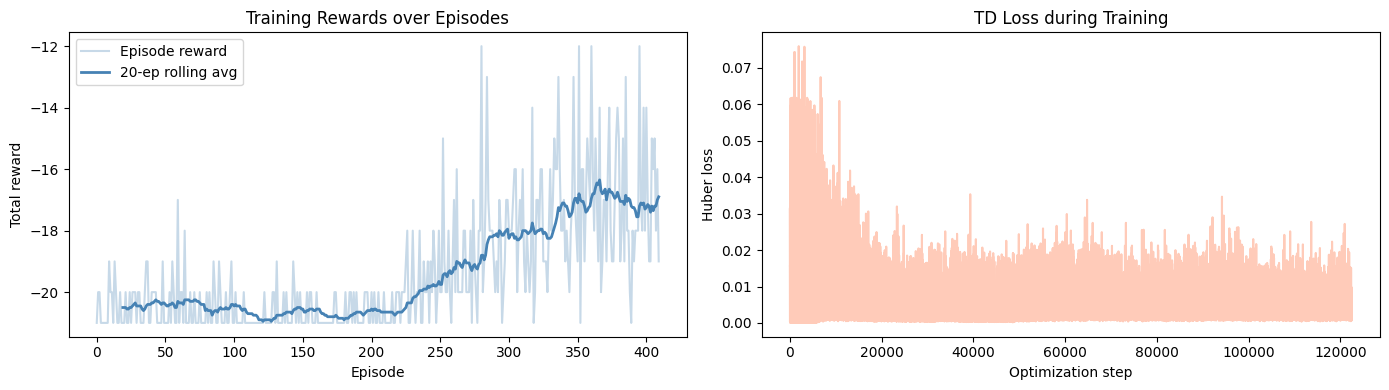

Total episodes    : 410
Best episode      : -12.0
Final 20-ep avg   : -16.90


In [11]:
window = 20
rewards_arr = np.array(episode_rewards)
rolling_avg = np.convolve(rewards_arr, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rewards_arr, alpha=0.3, color='steelblue', label='Episode reward')
axes[0].plot(np.arange(window - 1, len(rewards_arr)), rolling_avg,
             color='steelblue', linewidth=2, label=f'{window}-ep rolling avg')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].set_title('Training Rewards over Episodes')
axes[0].legend()

axes[1].plot(losses, alpha=0.4, color='coral')
axes[1].set_xlabel('Optimization step')
axes[1].set_ylabel('Huber loss')
axes[1].set_title('TD Loss during Training')

plt.tight_layout()
plt.show()

print(f'Total episodes    : {len(episode_rewards)}')
print(f'Best episode      : {max(episode_rewards):.1f}')
print(f'Final 20-ep avg   : {np.mean(episode_rewards[-20:]):.2f}')

In [12]:
def evaluate_agent(policy_net, n_episodes=10, seed=100):
    """Run trained agent with epsilon=0 and return per-episode rewards."""
    eval_env = make_env(seed=seed)
    policy_net.eval()
    rewards = []
    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=seed + ep)
        total, done = 0, False
        while not done:
            with torch.no_grad():
                state_t = torch.tensor(np.array(state), device=device, dtype=torch.float32).unsqueeze(0) / 255.0
                action  = policy_net(state_t).argmax(dim=1).item()
            state, r, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total += r
        rewards.append(total)
        print(f'  Eval ep {ep + 1:>2}: {total:.1f}')
    eval_env.close()
    policy_net.train()
    return rewards


print('Evaluating DQN agent (epsilon = 0)...')
dqn_rewards = evaluate_agent(policy_net, n_episodes=10)
print(f'\nDQN  mean: {np.mean(dqn_rewards):.2f}  std: {np.std(dqn_rewards):.2f}')

Evaluating DQN agent (epsilon = 0)...
  Eval ep  1: -12.0
  Eval ep  2: -19.0
  Eval ep  3: -20.0
  Eval ep  4: -16.0
  Eval ep  5: -20.0
  Eval ep  6: -21.0
  Eval ep  7: -16.0
  Eval ep  8: -19.0
  Eval ep  9: -20.0
  Eval ep 10: -16.0

DQN  mean: -17.90  std: 2.66


Evaluating random agent...
Random mean: -19.90  std: 0.83


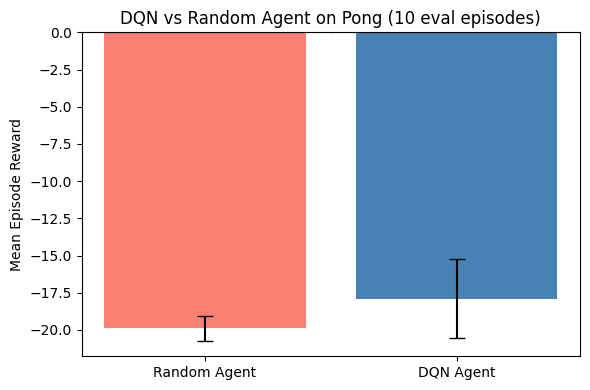

In [13]:
def evaluate_random(n_episodes=10, seed=100):
    """Run a purely random agent as a baseline."""
    eval_env = make_env(seed=seed)
    rewards = []
    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=seed + ep)
        total, done = 0, False
        while not done:
            action = eval_env.action_space.sample()
            state, r, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            total += r
        rewards.append(total)
    eval_env.close()
    return rewards


print('Evaluating random agent...')
random_rewards = evaluate_random(n_episodes=10)
print(f'Random mean: {np.mean(random_rewards):.2f}  std: {np.std(random_rewards):.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ['Random Agent', 'DQN Agent'],
    [np.mean(random_rewards), np.mean(dqn_rewards)],
    yerr=[np.std(random_rewards), np.std(dqn_rewards)],
    color=['salmon', 'steelblue'],
    capsize=6,
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Episode Reward')
ax.set_title('DQN vs Random Agent on Pong (10 eval episodes)')
plt.tight_layout()
plt.show()

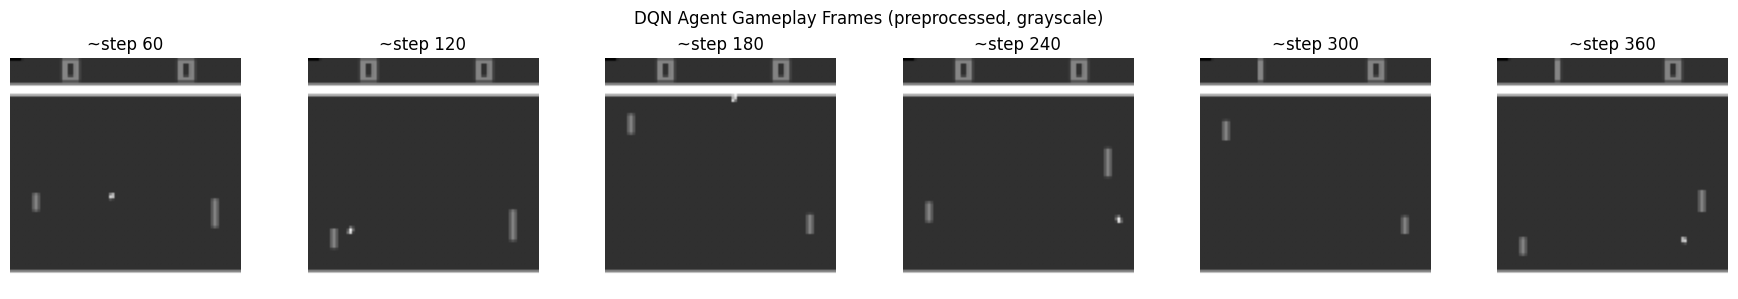

In [14]:
def render_gameplay(policy_net, n_frames=6, seed=99, frame_interval=15):
    """Capture and display frames from a trained agent episode."""
    render_env = gym.make('ALE/Pong-v5', render_mode='rgb_array', frameskip=1)
    render_env = AtariPreprocessing(render_env, noop_max=30, frame_skip=4,
                                    screen_size=84, terminal_on_life_loss=True,
                                    grayscale_obs=True, scale_obs=False)
    render_env = make_frame_stack(render_env, 4)

    state, _ = render_env.reset(seed=seed)
    frames, step, done = [], 0, False
    policy_net.eval()

    with torch.no_grad():
        while not done and len(frames) < n_frames * frame_interval:
            state_t = torch.tensor(np.array(state), device=device, dtype=torch.float32).unsqueeze(0) / 255.0
            action  = policy_net(state_t).argmax(dim=1).item()
            state, _, terminated, truncated, _ = render_env.step(action)
            done = terminated or truncated
            step += 1
            if step % frame_interval == 0:
                frames.append(np.array(state)[3])  # last frame in stack (uint8)

    render_env.close()
    policy_net.train()

    n = min(n_frames, len(frames))
    if n == 0:
        print('Episode ended before any frames were captured.')
        return

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes[:n]):
        ax.imshow(frames[i], cmap='gray')
        ax.set_title(f'~step {(i + 1) * frame_interval * 4}')
        ax.axis('off')
    plt.suptitle('DQN Agent Gameplay Frames (preprocessed, grayscale)')
    plt.tight_layout()
    plt.show()


render_gameplay(policy_net)

## 7. Discussion

### Training Results Summary

| Metric | Value |
|---|---|
| Total steps | 500,000 |
| Total episodes | 410 |
| Training time (T4 GPU) | ~26 minutes |
| Starting avg reward (ep 1-20) | -20.60 |
| Final avg reward (last 20 ep) | -16.90 |
| Best single episode | -12.0 |
| DQN eval mean (10 ep, eps=0) | -17.90 (std 2.66) |
| Random agent mean (10 ep) | -19.90 (std 0.83) |

### What the Results Show

The agent **did learn**, but only partially. Reward improved by roughly 4 points over 500k steps (from -20.6 to -16.9), and the DQN outperforms a random agent by ~2 points on average. The best single episode reached -12.0, meaning the agent occasionally wins a few points against the opponent.

However, the policy is far from competitive. A fully trained DQN on Pong typically reaches rewards above 0 (winning more points than it loses) after 1-2M steps. At 500k steps we are still in the early learning phase.

**Key pattern in the training log:** reward stayed flat at around -20.5 for the first 200k steps (while epsilon was still high and the agent was mostly exploring), then started improving steadily once epsilon reached 0.1 at step 100k and the learned Q-values began to guide action selection. The visible improvement from step 210k onward confirms the agent is extracting a useful signal from the replay buffer.

### Why DQN Needs Two Stability Tricks

**1. Correlated samples**
Consecutive environment steps are highly correlated (frame t and frame t+1 look nearly identical). Training on sequential data causes the network to overfit to local patterns. The replay buffer breaks this correlation by sampling random mini-batches from a pool of 50,000 past transitions.

**2. Moving targets**
The TD target `r + gamma * max Q(s', a')` uses the same network being updated, creating a feedback loop that can diverge. The target network decouples this by holding a frozen copy updated only every 1,000 steps.

### Design Choices and Tradeoffs

- **uint8 replay buffer storage:** Storing observations as uint8 (0-255) instead of float32 reduces RAM significantly. The full training run peaked at ~5 GB (vs crashing with float32 at ~11 GB). Conversion to float32 and normalization to [0, 1] happens at sample time on the GPU.
- **Pong over Breakout/SpaceInvaders:** Pong has the simplest strategy (follow the ball, 6 actions), making it the fastest Atari game to show learning. Even so, 500k steps is not enough for full convergence - 1-2M steps is the typical requirement.
- **Frame skip = 4:** Reduces computation by 4x and matches human reaction-time scale. The built-in `frameskip` in `ALE/Pong-v5` must be disabled (`frameskip=1`) so `AtariPreprocessing` can manage it without double-skipping.
- **Huber loss over MSE:** TD errors are large early in training. Huber loss is quadratic for small errors and linear for large ones, limiting the impact of outlier TD targets.
- **Epsilon decay over 100k steps:** The agent stayed near -20 reward until epsilon reached 0.1, at which point learned Q-values started driving decisions and reward began to improve. A slower decay (over 200k steps) might help on longer runs.

### What Would Improve Results

- **More steps (1-2M):** The trend in the log is clearly downward (improving) at 500k; given more time the agent would likely reach competitive play.
- **Double DQN:** Addresses Q-value overestimation by decoupling action selection and evaluation between online and target networks.
- **Prioritized experience replay:** Samples transitions with high TD error more frequently, speeding up learning from rare but important events.